# Поиск аномалий

Обнаружение аномалий - важнейший метод анализа данных, используемый для выявления необычных закономерностей или наблюдений, которые значительно отличаются от ожидаемого поведения. В различных областях, таких как кибербезопасность, обнаружение мошенничества и мониторинг работоспособности систем, обнаружение аномалий играет жизненно важную роль в выявлении потенциальных проблем или угроз.

В случае сильно несбалансированных наборов данных стоит задуматься, могут ли такие примеры рассматриваться как аномалия (выброс) или нет. Если такое событие и впрямь может считаться аномальным, мы можем использовать такие модели, как OneClassSVM, методы кластеризации или методы обнаружения гауссовских аномалий.

Эти методы требуют изменения взгляда на задачу: мы будем рассматривать аномалии как отдельный класс выбросов. Это может помочь нам найти новые способы разделения и классификации.

Пусть мы хотим отличать фрукты по каким-то признакам, скажем, по форме и цвету, и мы имеем выборку, где много яблок и груш. Задача обнаружения аномалий возникает, если мы предполагаем, что среди яблок и груш может вдруг возникнуть клубника и нам нужно отнести ее не к одному из известных классов, а выделить в отдельный, отличающийся класс.

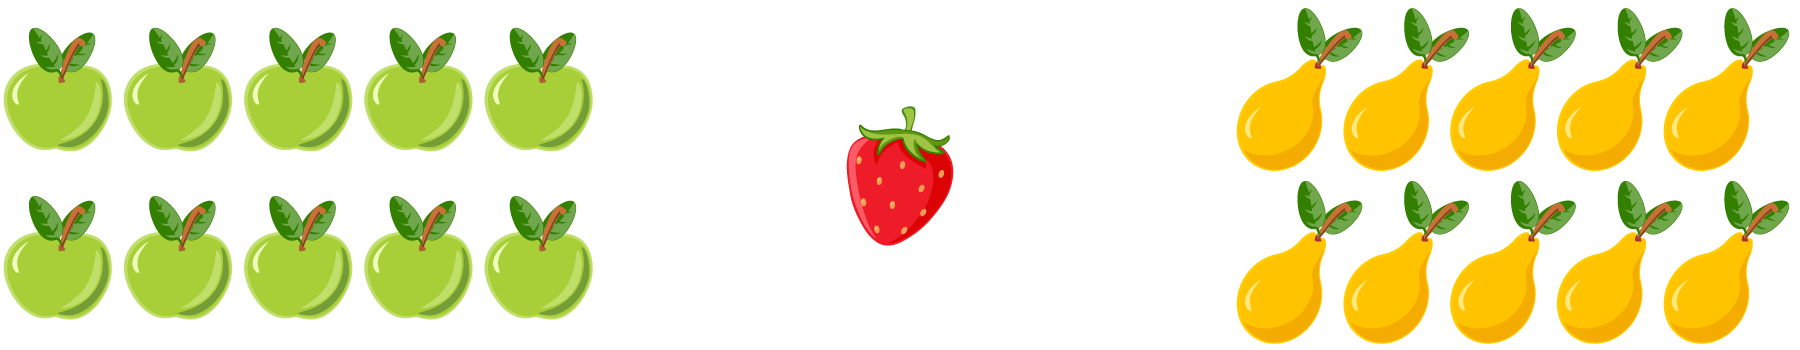

Проблемой при работе с аномалиями является то, что аномальных значений может быть очень мало или вообще не быть. В таком случае алгоритм учит паттерны нормального поведения и реагирует на отличия от паттернов.

Создадим датасет из двух кластеров и случайных значений.

In [ ]:
import numpy as np

rng = np.random.RandomState(42)

# Train
x = 0.3 * rng.randn(100, 2)  # 100 2D points
x_train = np.r_[x + 2, x - 2]  # split into two clusters

# Test norlmal
x = 0.3 * rng.randn(20, 2)  # 20 2D points
x_test_normal = np.r_[x + 2, x - 2]  # split into two clusters

# Test outliers
x_test_outliers = rng.uniform(low=-4, high=4, size=(20, 2))

Напишем функцию визуализации, которая будет изображать созданный датасет на рисунке слева, а результат поиска аномалий — на рисунке справа.

In [ ]:
def plot_outliers(x_train, x_test_normal, x_test_outliers, model=None):
    fig, (plt_data, plt_model) = plt.subplots(1, 2, figsize=(12, 6))

    plt_data.set_title("Created Dataset (real labels)")
    plot_train = plt_data.scatter(
        x_train[:, 0], x_train[:, 1], c="white", s=40, edgecolor="k"
    )
    plot_test_normal = plt_data.scatter(
        x_test_normal[:, 0], x_test_normal[:, 1], c="green", s=40, edgecolor="k"
    )
    plot_test_outliers = plt_data.scatter(
        x_test_outliers[:, 0], x_test_outliers[:, 1], c="red", s=40, edgecolor="k"
    )

    plt_data.set_xlim((-5, 5))
    plt_data.set_ylim((-5, 5))

    plt_data.legend(
        [plot_train, plot_test_normal, plot_test_outliers],
        ["train", "test normal", "test outliers"],
        loc="lower right",
    )

    if model:
        plt_model.set_title("Model Results")
        # plot decision function
        xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt_model.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

        # plot prediction
        full_data = np.concatenate((x_train, x_test_normal, x_test_outliers), axis=0)
        predicted = model.predict(full_data)

        anom_index = np.where(predicted == -1)
        anom_values = full_data[anom_index]

        plot_all_data = plt_model.scatter(
            full_data[:, 0], full_data[:, 1], c="white", s=40, edgecolor="k"
        )

        plot_anom_data = plt_model.scatter(
            anom_values[:, 0], anom_values[:, 1], c="red", s=40, marker="x"
        )
        plt_model.legend(
            [plot_all_data, plot_anom_data],
            ["normal", "outliers"],
            loc="lower right",
        )
    plt.show()

На прошлой практике мы уже познакомились с алгоритмом DBSCAN. Его основная цель - кластеризация, но он так же позволяет находить точки шума, а потому его тоже можно использовать для задачи поиска аномалий.

[demo] [🎮 Интерактивная визуализация алгоритма DBSCAN](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/)

In [ ]:
def plot_outliers_dbscan(x_train, x_test_normal, x_test_outliers, model=None):
    fig, (plt_data, plt_model) = plt.subplots(1, 2, figsize=(12, 6))

    plt_data.set_title("Created Dataset (real labels)")
    plot_train = plt_data.scatter(
        x_train[:, 0], x_train[:, 1], c="white", s=40, edgecolor="k"
    )
    plot_test_normal = plt_data.scatter(
        x_test_normal[:, 0], x_test_normal[:, 1], c="green", s=40, edgecolor="k"
    )
    plot_test_outliers = plt_data.scatter(
        x_test_outliers[:, 0], x_test_outliers[:, 1], c="red", s=40, edgecolor="k"
    )

    plt_data.set_xlim((-5, 5))
    plt_data.set_ylim((-5, 5))

    plt_data.legend(
        [plot_train, plot_test_normal, plot_test_outliers],
        ["train", "test normal", "test outliers"],
        loc="lower right",
    )

    if model:
        plt_model.set_title("DBSCAN Results")

        # Объединяем все данные для предсказания
        full_data = np.concatenate((x_train, x_test_normal, x_test_outliers), axis=0)

        # Для DBSCAN нужно использовать fit_predict на всех данных
        model_all = DBSCAN(eps=eps, min_samples=min_samples)
        predicted_all = model_all.fit_predict(full_data)

        # Находим выбросы (шум) - точки с меткой -1
        anom_index = np.where(predicted_all == -1)
        anom_values = full_data[anom_index]

        # Визуализация кластеров
        unique_labels = set(predicted_all)
        colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Черный цвет для шума
                col = 'black'

            class_member_mask = (predicted_all == k)
            xy = full_data[class_member_mask]

            if k == -1:
                # Шум (выбросы) отображаем крестиками
                plt_model.scatter(
                    xy[:, 0], xy[:, 1],
                    c='red', s=40, marker='x',
                    edgecolor='k', label='outliers'
                )
            else:
                # Точки кластеров
                plt_model.scatter(
                    xy[:, 0], xy[:, 1],
                    c=[col], s=40, edgecolor='k',
                    label=f'cluster {k}'
                )

        # Убираем дубликаты в легенде
        handles, labels = plt_model.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt_model.legend(by_label.values(), by_label.keys(), loc="lower right")

        # Добавляем границы графика
        plt_model.set_xlim((-5, 5))
        plt_model.set_ylim((-5, 5))

    plt.show()

/tmp/ipykernel_366/396156932.py:52: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt_model.scatter(


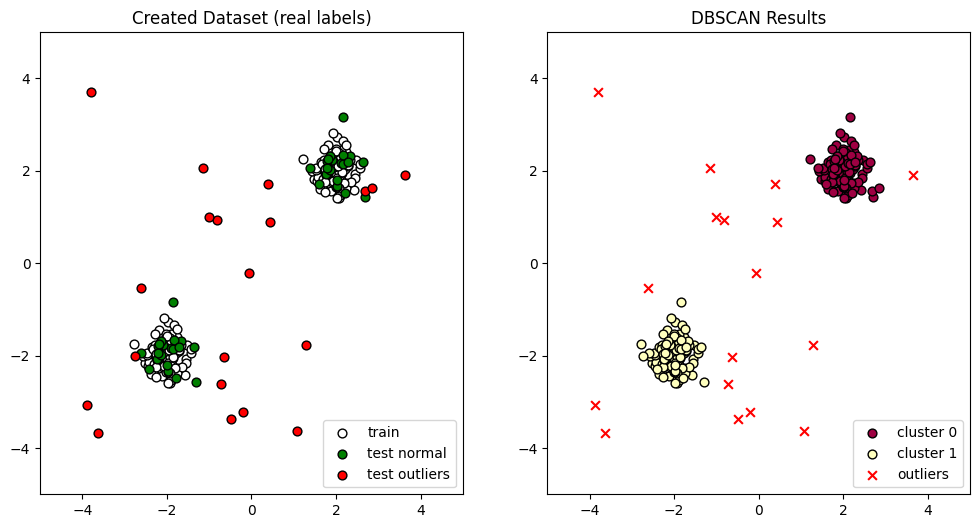

In [ ]:
from sklearn.cluster import DBSCAN

eps = 0.5  # максимальное расстояние между соседними точками
min_samples = 10  # минимальное количество точек для формирования кластера

model = DBSCAN(eps=eps, min_samples=min_samples)
model.fit(x_train)

plot_outliers_dbscan(x_train, x_test_normal, x_test_outliers, model)

Но помимо DBSCAN существуют алгоритмы, которые направлены именно на поиск аномалий. У них есть специальный параметр, позволяющий определять порог шума.

Посмотрим, как работает на этих данных алгоритм OneClassSVM.

OCSVM основывается на предпосылке, что большинство реальных данных по своей природе являются нормальными. В большинстве случаев выбросы или аномалии — это редкие явления, которые существенно отклоняются от обычных закономерностей. Цель OCSVM — определить границу, инкапсулирующую нормальные экземпляры в пространстве признаков.

То есть его идея состоит в поиске функции, которая положительна для областей с высокой плотностью и отрицательна для областей с малой плотностью.

Подробнее об самом алгоритме, и чем он отличается от обычного SVM: [ссылка](https://www.geeksforgeeks.org/machine-learning/understanding-one-class-support-vector-machines/)


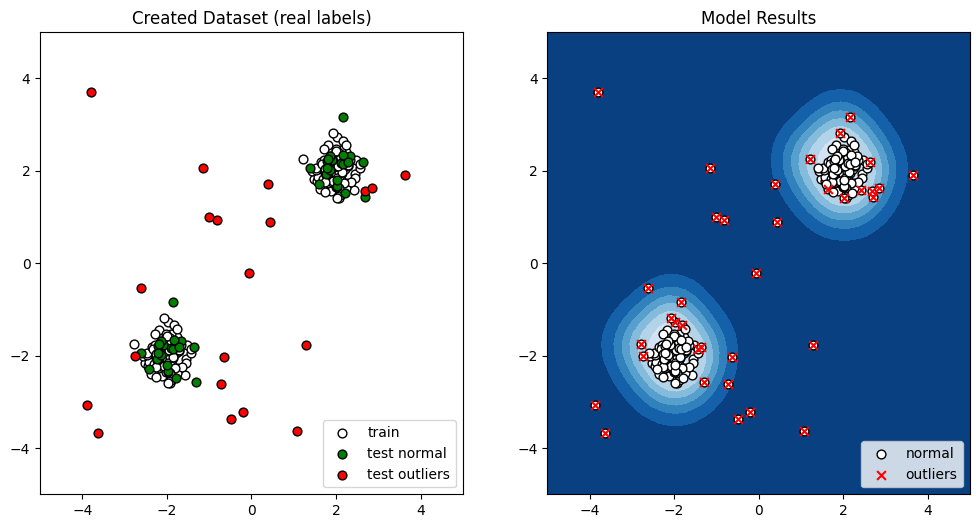

In [ ]:
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt

gamma = 2.0  # Kernel coefficient
contamination = 0.05  # threshold

model = OneClassSVM(gamma=gamma, kernel="rbf", nu=contamination)
model.fit(x_train)

plot_outliers(x_train, x_test_normal, x_test_outliers, model)

Посмотрим, как на этих же данных работает алгоритм Isolation Forest.

Isolation Forest состоит из деревьев, которые «изолируют» (пытаются отделить от остальной выборки) наблюдения, случайным образом выбирая признак и случайное значение порога для этого признака (между max и min значениями признака). Такой алгоритм чаще и проще отделяет значения аномалий. Если построить по такому принципу множество деревьев, то значения, которые чаще других отделяются раньше, будут аномалиями.

На практике часто используют более продвинутую версию Extended Isolation Forest.

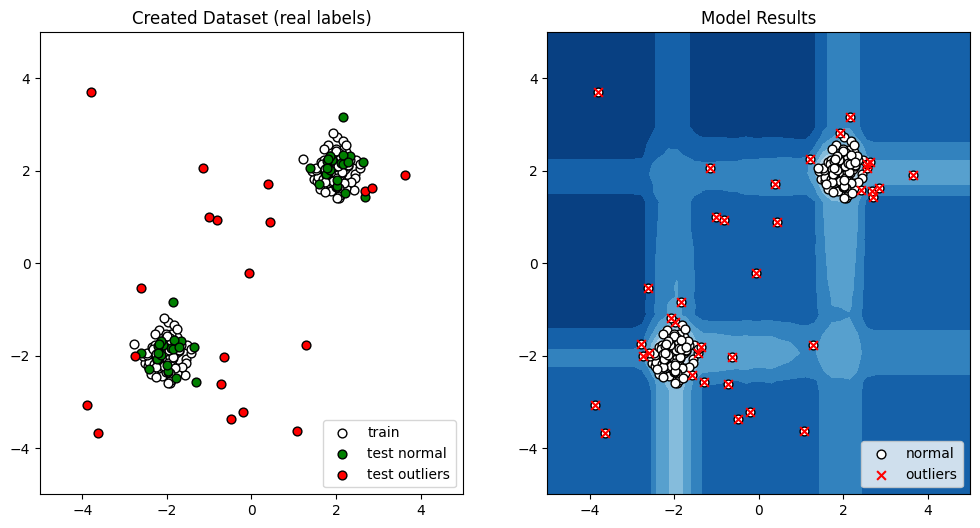

In [ ]:
from sklearn.ensemble import IsolationForest

n_estimators = 200
contamination = 0.05  # threshold

model = IsolationForest(
    n_estimators=n_estimators, contamination=contamination, random_state=rng
)
model.fit(x_train)

plot_outliers(x_train, x_test_normal, x_test_outliers, model)

Последним алгоритмом, на который мы посмотрим, будет Local Outlier Factor.

В нем используется метод k-NN. Расстояние до ближайших соседей используется для оценки расположения точек. Если соседи далеко, то точка с большой вероятностью является аномалией.

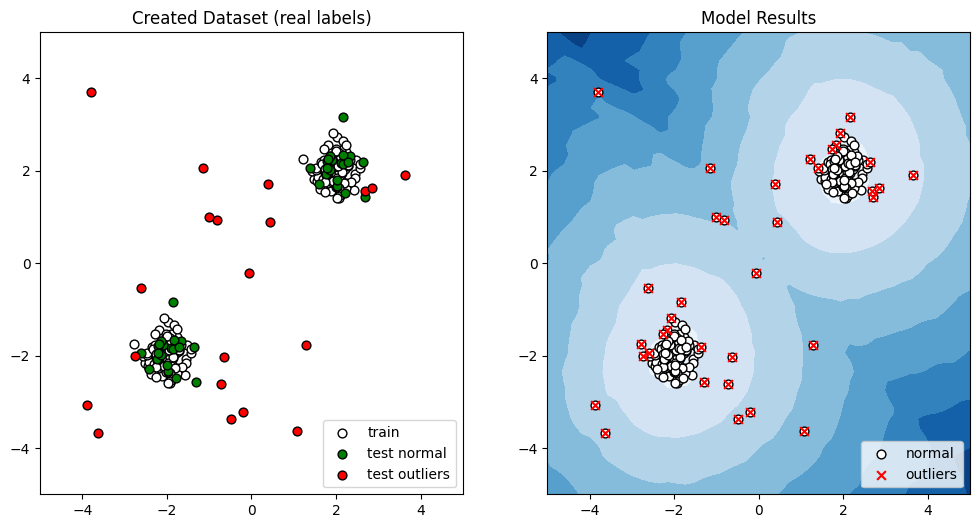

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

n_neighbors = 10
contamination = 0.05  # threshold

model = LocalOutlierFactor(
    n_neighbors=n_neighbors, novelty=True, contamination=contamination
)
model.fit(x_train)

plot_outliers(x_train, x_test_normal, x_test_outliers, model)

## Оценка качества в задаче обнаружения аномалий

Отдельное время стоит посвятить подбору порога для алгоритма.

Порог является граничным значением, выше которого данные считаются аномальными. Выбор порога — это компромиссное решение: слишком низкий порог может привести к ложным срабатываниям, тогда как слишком высокий порог может пропустить аномалии. Поэтому выбор порога напрямую связан с задачей и требованиям к детекции.

Построим матрицы ошибок (Confusion matrix) для разных порогов:

In [ ]:
full_data = np.concatenate((x_train, x_test_normal, x_test_outliers), axis=0)
predicted = model.predict(full_data)

# change threshold to 0.005
model_2 = LocalOutlierFactor(n_neighbors=10, novelty=True, contamination=0.005)
model_2.fit(x_train)
predicted_2 = model_2.predict(full_data)

y_true = np.ones(full_data.shape[0])  # create true labels
y_true[-x_test_outliers.shape[0] :] = -1  # last 20 is anomaly

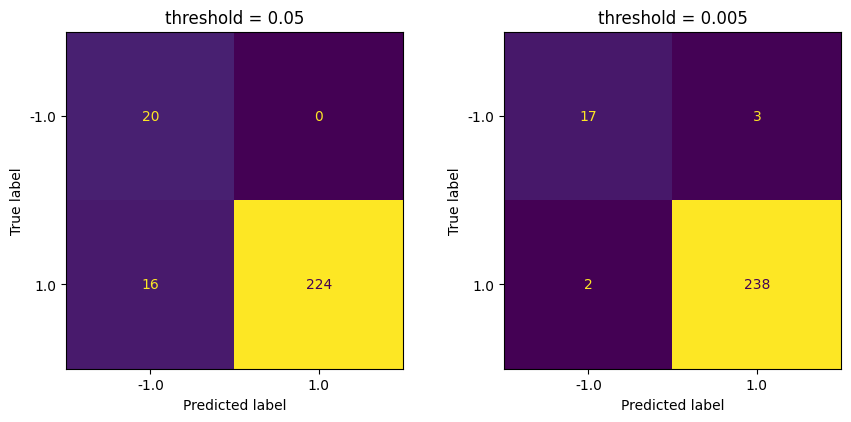

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ConfusionMatrixDisplay.from_predictions(y_true, predicted, ax=ax1, colorbar=False)
ConfusionMatrixDisplay.from_predictions(y_true, predicted_2, ax=ax2, colorbar=False)
ax1.set_title("threshold = 0.05")
ax2.set_title("threshold = 0.005")
plt.subplots_adjust(wspace=0.3)
plt.show()

## Cравнение алгоритмов обнаружения выбросов в scikit-learn.

Local Outlier Factor (LOF) не показывает границу принятия решения черным цветом, так как не имеет метода предсказания, применяемого к новым данным, когда он используется для обнаружения выбросов.

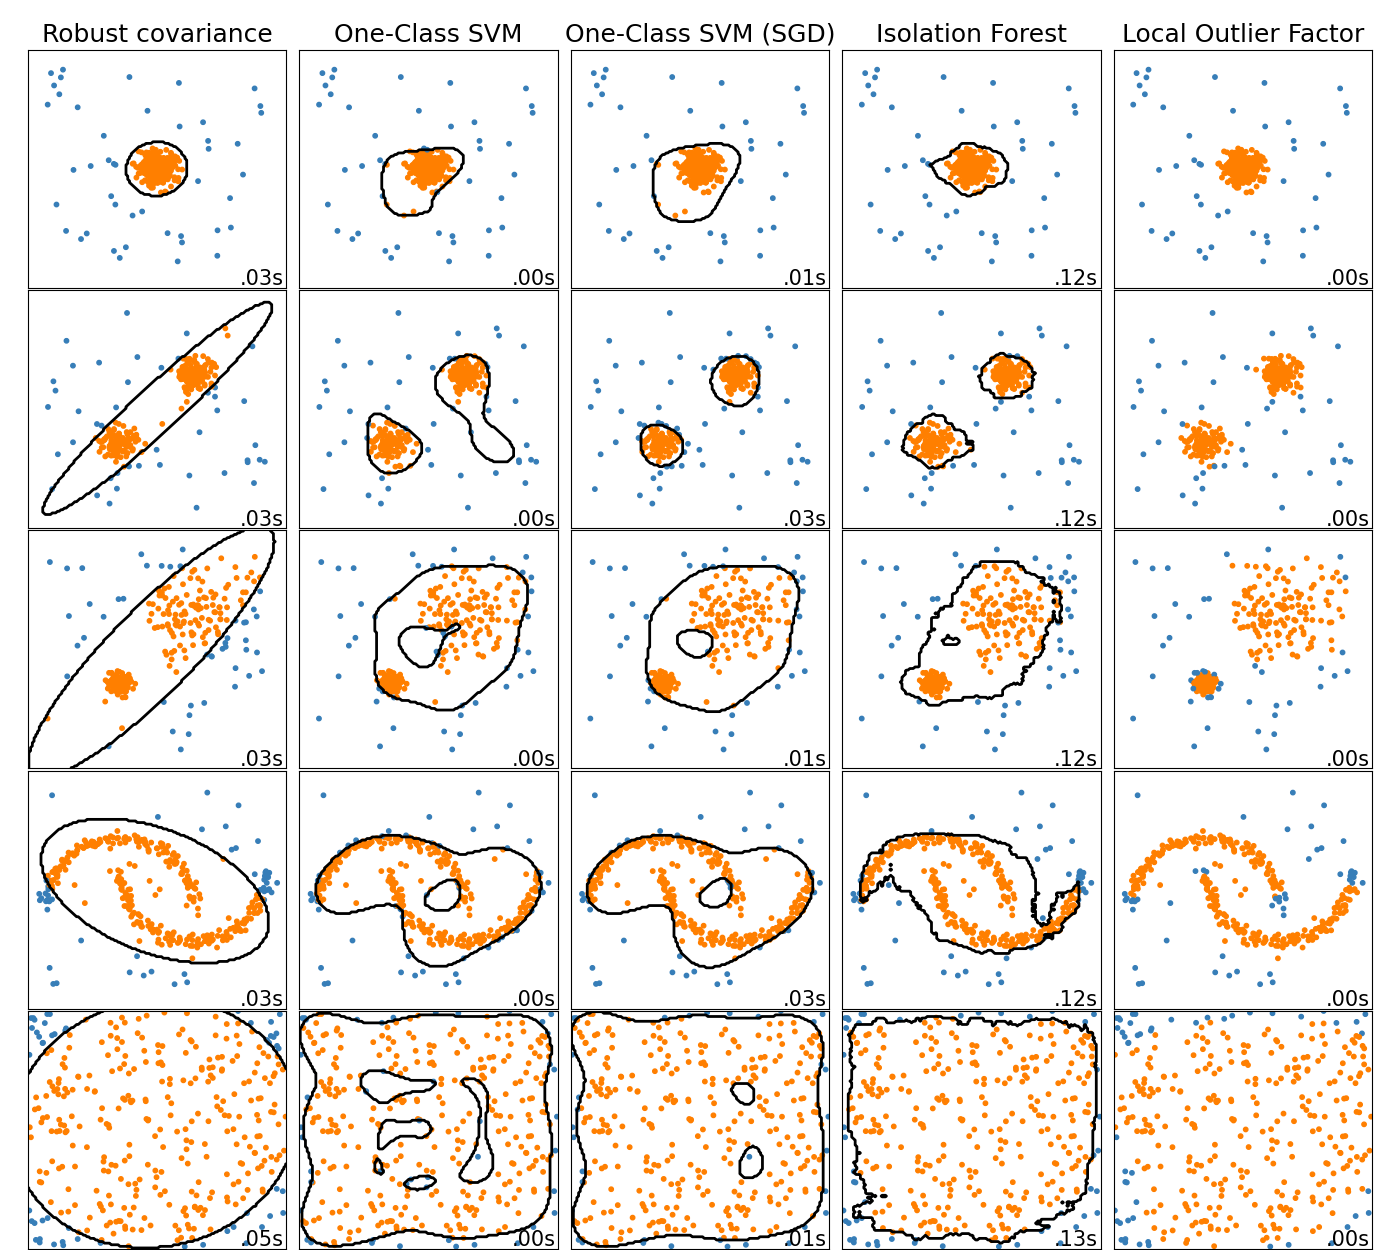

Чтобы использовать neighbors.LocalOutlierFactor для обнаружения аномалий в новых данных, необходимо инициализировать модель с параметром novelty, установленным в True перед обучением модели:

In [ ]:
lof = LocalOutlierFactor(novelty=True)
lof.fit(X_train)

Если для novelty установлено значение True, помните, что вы должны использовать predict, decision_function и score_samples только на новых невидимых ранее данных, а не на обучающих выборках, так как это приведет к неправильным результатам. То есть результат predict не будет совпадать с результатом fit_predict. Оценки ненормальности обучающих выборок всегда доступны через атрибут negative_outlier_factor_.